# Encoder and embedding-size comparison

The chart uses the saved SLoD spans and five repetitions of paper-grouped 5-fold evaluation (seeds 42–46). All encoders have a 256-model-token input limit; logistic regression uses `C=1`. Sizes 16–128 use PCA fitted only on each training fold. Hollow points mark native dimensions (384 for MiniLM, 768 for MPNet). The horizontal TF-IDF and word-count baselines have no embedding size.

The saved results below reproduce the values in `TECHNICAL_REPORT.md`. Set `RECOMPUTE = True` to rerun the complete comparison with `src/cross_validate.py`. Model cards: [MiniLM-L6](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), [MiniLM-L12](https://huggingface.co/sentence-transformers/all-MiniLM-L12-v2), [MPNet](https://huggingface.co/sentence-transformers/all-mpnet-base-v2).

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set True to rerun all encoders and PCA folds; this takes several minutes on CPU.
RECOMPUTE = False
if RECOMPUTE:
    import sys
    sys.path.insert(0, str(Path.cwd() / "src"))
    from cross_validate import run_model_size_comparison
    results = run_model_size_comparison()
else:
    results = json.loads(r'''{"evaluation":"NLP paper-grouped repeated 5-fold; seeds 42-46","encoder_max_tokens":256,"probe_C":1.0,"bootstrap_replicates":2000,"reduced_dimensions":[16,32,64,128],"baselines":{"length":0.3084632122706837,"tfidf":0.5871426035725202},"models":[{"model":"sentence-transformers/all-MiniLM-L6-v2","embedding_size":16,"reduction":"PCA fit on training fold","macro_f1":0.548015323653226,"macro_f1_per_repeat":[0.5459829617591262,0.5533981762644066,0.5544932288317028,0.5358703426022409,0.5503319088086536],"macro_f1_ci95_paper_bootstrap":[0.520350925711221,0.576206127682678],"accuracy":0.5557333333333333,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-MiniLM-L6-v2","embedding_size":32,"reduction":"PCA fit on training fold","macro_f1":0.5688476072237489,"macro_f1_per_repeat":[0.564597317895158,0.5785720458892216,0.5753657894785444,0.5652316769054863,0.5604712059503344],"macro_f1_ci95_paper_bootstrap":[0.5405686926058481,0.5978522455338884],"accuracy":0.5736,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-MiniLM-L6-v2","embedding_size":64,"reduction":"PCA fit on training fold","macro_f1":0.5710983776338002,"macro_f1_per_repeat":[0.5859962587287209,0.5667798226627306,0.5716521797337589,0.5695070066154765,0.5615566204283146],"macro_f1_ci95_paper_bootstrap":[0.5435831578963983,0.5973773435611562],"accuracy":0.576,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-MiniLM-L6-v2","embedding_size":128,"reduction":"PCA fit on training fold","macro_f1":0.5637829326482293,"macro_f1_per_repeat":[0.56516231889996,0.5720712153174027,0.5757517098980514,0.5442411412294696,0.561688277896263],"macro_f1_ci95_paper_bootstrap":[0.5362593951774843,0.5899768608508374],"accuracy":0.5650666666666667,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-MiniLM-L6-v2","embedding_size":384,"reduction":"native","macro_f1":0.5187120581332904,"macro_f1_per_repeat":[0.5299044486029855,0.5299608583887935,0.5274857163442487,0.5150155541278981,0.49119371320252575],"macro_f1_ci95_paper_bootstrap":[0.4923214792673981,0.5451641243506359],"accuracy":0.5189333333333334,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-MiniLM-L12-v2","embedding_size":16,"reduction":"PCA fit on training fold","macro_f1":0.5311443074803375,"macro_f1_per_repeat":[0.5339967581286511,0.5373019404719145,0.5360076548641278,0.514959080495845,0.533456103441149],"macro_f1_ci95_paper_bootstrap":[0.5056471242657034,0.5584604986299008],"accuracy":0.5397333333333333,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-MiniLM-L12-v2","embedding_size":32,"reduction":"PCA fit on training fold","macro_f1":0.5743480888484365,"macro_f1_per_repeat":[0.5754991533310162,0.5834341273732931,0.569238308693,0.566731558863629,0.5768372959812438],"macro_f1_ci95_paper_bootstrap":[0.54705973132949,0.6009712535401612],"accuracy":0.5792,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-MiniLM-L12-v2","embedding_size":64,"reduction":"PCA fit on training fold","macro_f1":0.5717311290953828,"macro_f1_per_repeat":[0.5706598763833391,0.5699163105413105,0.6000009910824461,0.5580634409917097,0.5600150264781086],"macro_f1_ci95_paper_bootstrap":[0.544683039392584,0.5986753882145459],"accuracy":0.5765333333333333,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-MiniLM-L12-v2","embedding_size":128,"reduction":"PCA fit on training fold","macro_f1":0.5594130181494686,"macro_f1_per_repeat":[0.5705144819542539,0.5558461281820305,0.5820198038062961,0.5366570058329924,0.5520276709717704],"macro_f1_ci95_paper_bootstrap":[0.5328837755445078,0.5862939841696823],"accuracy":0.5608,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-MiniLM-L12-v2","embedding_size":384,"reduction":"native","macro_f1":0.5372519820642896,"macro_f1_per_repeat":[0.5382786646843898,0.5248260885733013,0.5592785568833473,0.5160689146210712,0.5478076855593382],"macro_f1_ci95_paper_bootstrap":[0.5119832141384577,0.5621340911986631],"accuracy":0.5370666666666667,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-mpnet-base-v2","embedding_size":16,"reduction":"PCA fit on training fold","macro_f1":0.5204408986328731,"macro_f1_per_repeat":[0.5256222930740074,0.512350471303333,0.5382776385516667,0.5146747688588323,0.5112793213765262],"macro_f1_ci95_paper_bootstrap":[0.4947020721119957,0.5447470297590856],"accuracy":0.5290666666666667,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-mpnet-base-v2","embedding_size":32,"reduction":"PCA fit on training fold","macro_f1":0.5459371402212765,"macro_f1_per_repeat":[0.5447531757413645,0.5479711785898096,0.5369046473290866,0.5487630263866607,0.5512936730594609],"macro_f1_ci95_paper_bootstrap":[0.5188064822310583,0.571355829538109],"accuracy":0.5533333333333333,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-mpnet-base-v2","embedding_size":64,"reduction":"PCA fit on training fold","macro_f1":0.5622139138903333,"macro_f1_per_repeat":[0.5775586958427098,0.5392739873960966,0.5683957263179232,0.564578509138952,0.5612626507559848],"macro_f1_ci95_paper_bootstrap":[0.5335338955176271,0.5897409611251776],"accuracy":0.5658666666666666,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-mpnet-base-v2","embedding_size":128,"reduction":"PCA fit on training fold","macro_f1":0.5525809881872942,"macro_f1_per_repeat":[0.5573976057870814,0.5453695723222632,0.5561427723899119,0.5629538544866738,0.5410411359505406],"macro_f1_ci95_paper_bootstrap":[0.5256490205054729,0.5771135324757538],"accuracy":0.5536,"test_papers":348,"unique_test_spans":750},{"model":"sentence-transformers/all-mpnet-base-v2","embedding_size":768,"reduction":"native","macro_f1":0.5420049604322019,"macro_f1_per_repeat":[0.5325914839157502,0.5428358081583888,0.5550771724733886,0.536332926028884,0.5431874115845978],"macro_f1_ci95_paper_bootstrap":[0.5162635116000226,0.5684492913892072],"accuracy":0.5408,"test_papers":348,"unique_test_spans":750}]}''')


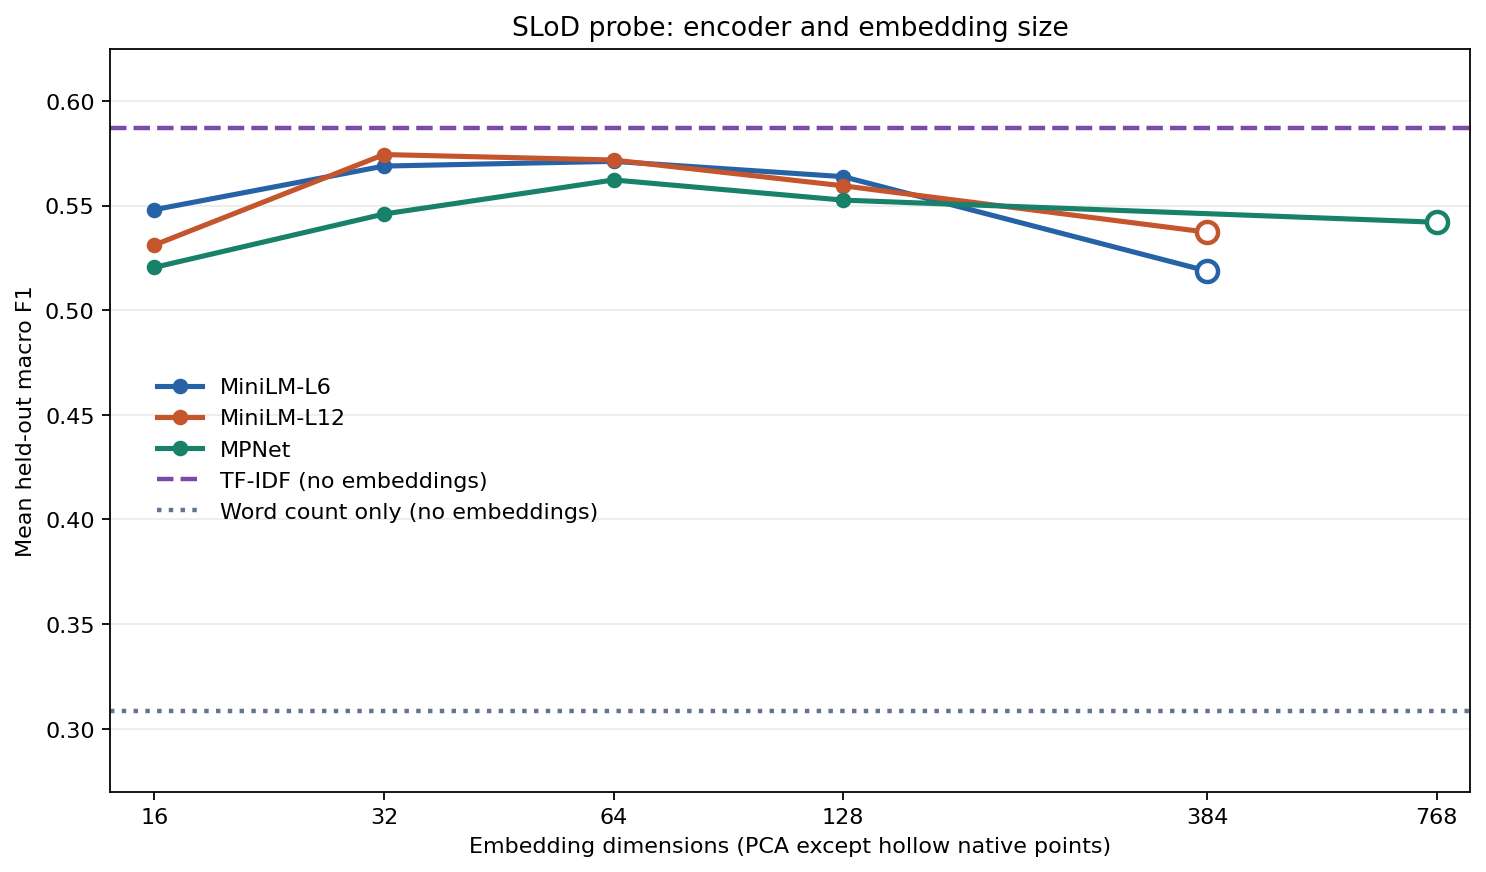

In [2]:
frame = pd.DataFrame(results["models"])
labels = {
    "sentence-transformers/all-MiniLM-L6-v2": "MiniLM-L6",
    "sentence-transformers/all-MiniLM-L12-v2": "MiniLM-L12",
    "sentence-transformers/all-mpnet-base-v2": "MPNet",
}
colors = {"MiniLM-L6": "#2563a6", "MiniLM-L12": "#c4552d", "MPNet": "#18816a"}
fig, ax = plt.subplots(figsize=(9.4, 5.6))
for model, group in frame.groupby("model", sort=False):
    group = group.sort_values("embedding_size")
    name = labels[model]
    ax.plot(group["embedding_size"], group["macro_f1"], marker="o", lw=2.3,
            ms=6, color=colors[name], label=name)
    native = group[group["reduction"] == "native"].iloc[0]
    ax.scatter([native["embedding_size"]], [native["macro_f1"]],
               s=90, facecolor="white", edgecolor=colors[name], lw=2, zorder=5)
ax.axhline(results["baselines"]["tfidf"], color="#7a4aa6", ls="--", lw=2,
           label="TF-IDF (no embeddings)")
ax.axhline(results["baselines"]["length"], color="#64748b", ls=":", lw=2,
           label="Word count only (no embeddings)")
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 384, 768], ["16", "32", "64", "128", "384", "768"])
ax.set_xlim(14, 850)
ax.set_ylim(0.27, 0.625)
ax.set_xlabel("Embedding dimensions (PCA except hollow native points)")
ax.set_ylabel("Mean held-out macro F1")
ax.set_title("SLoD probe: encoder and embedding size")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(0.02, 0.46), ncol=1)
fig.tight_layout()
plt.show()


TF-IDF uses the full saved text, while each encoder truncates at 256 model tokens. The highest observed embedding score is exploratory because the sizes were compared on the evaluation corpus. The 95% paper-bootstrap intervals and full numeric results are in `TECHNICAL_REPORT.md` and the `results` object above.